In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/drive/MyDrive/AI/week1/diabetes.csv')

# 확인
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
y=df['Outcome']
y.value_counts() # Outcome 값이 0과 1로 각각 몇 개씩 있는지 개수 확인
y

,Outcome
0,1
1,0
2,1
3,0
4,1
...,...
763,0
764,0
765,0
766,1


In [ ]:
X=df.drop('Outcome',axis=1) # Outcome 열을 제외한 나머지 입력 변수(특성)들을 X에 저장
X.head()                    # X의 상위 5개 행을 출력

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [ ]:
from sklearn.model_selection import train_test_split  # 데이터를 학습용/테스트용으로 나누는 함수 불러오기

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25,random_state=0)  # 데이터를 75%를 학습용 25%를 테스트용으로 나눔 난수를 0으로하여 시드 고정

In [ ]:
from sklearn.metrics import accuracy_score              # 정확도 평가 함수 불러오기
from sklearn.metrics import confusion_matrix            # 혼동행렬 평가 함수 불러오기


In [ ]:
from sklearn.linear_model import LogisticRegression     # LogisticRegression(분류) 모델 불러오기

clf_lr = LogisticRegression(random_state=0, max_iter=5000)  # LogisticRegression 모델 생성
# 모델이 학습 도중 100번 안에 최적값을 찾지 못할 수 있어서 반복 횟수를 5000으로 늘림
clf_lr.fit(X_train, y_train)    # 학습용 데이터로 모델 학습

pred_lr = clf_lr.predict(X_test)    #결과 예측

print ("\n--- Logistic Regression Classifier ---")
print (accuracy_score(y_test, pred_lr))               #정확도 출력
print (confusion_matrix(y_test, pred_lr))             #혼동행렬 출력


--- Logistic Regression Classifier ---
0.796875
[[117  13]
 [ 26  36]]


In [ ]:
from sklearn.tree import DecisionTreeClassifier      # DecisionTreeClassifier(분류) 모델 불러오기

clf_DT = DecisionTreeClassifier(random_state=0)       #  DecisionTreeClassifier 모델 생성
clf_DT.fit(X_train, y_train)                          # 학습용 데이터로 모델 학습

pred_DT = clf_DT.predict(X_test)                      #결과 예측

print ("\n--- DecisionTreeClassifier ---")
print (accuracy_score(y_test, pred_DT))               #정확도 출력
print (confusion_matrix(y_test, pred_DT))             #혼동행렬 출력


--- DecisionTreeClassifier ---
0.71875
[[102  28]
 [ 26  36]]


In [ ]:
from sklearn.ensemble import RandomForestClassifier   # RandomForestClassifier(분류) 모델 불러오기


clf_RF = RandomForestClassifier(random_state=0)     #  RandomForestClassifier 모델 생성
clf_RF.fit(X_train, y_train)                        # 학습용 데이터로 모델 학습

pred_RF = clf_RF.predict(X_test)                     #결과 예측

print ("\n--- RandomForestClassifier ---")
print (accuracy_score(y_test, pred_RF))               #정확도 출력
print (confusion_matrix(y_test, pred_RF))             #혼동행렬 출력


--- RandomForestClassifier ---
0.7708333333333334
[[116  14]
 [ 30  32]]


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

clf_knn = KNeighborsClassifier(n_neighbors=5)
clf_knn.fit(X_train, y_train)

pred_knn = clf_knn.predict(X_test)

print ("\n--- KNeighborsClassifier ---")
print (accuracy_score(y_test, pred_knn))
print (confusion_matrix(y_test, pred_knn))


--- KNeighborsClassifier ---
0.7552083333333334
[[109  21]
 [ 26  36]]


In [ ]:
# K값의 최적값을 찾기 위해 for문을 1~30까지 돌리고 그래프로 표현 Classifier에선 정확도가 가장 큰 값


--- KNeighborsClassifier 최적화 결과 ---
최적의 k: 10
최고 정확도: 0.78125

--- KNeighborsClassifier ---
정확도: 0.78125
혼동행렬:
 [[118  12]
 [ 30  32]]


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46384 (\N{HANGUL SYLLABLE DDA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47480 (\N{HANGUL SYLLABLE REUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/us

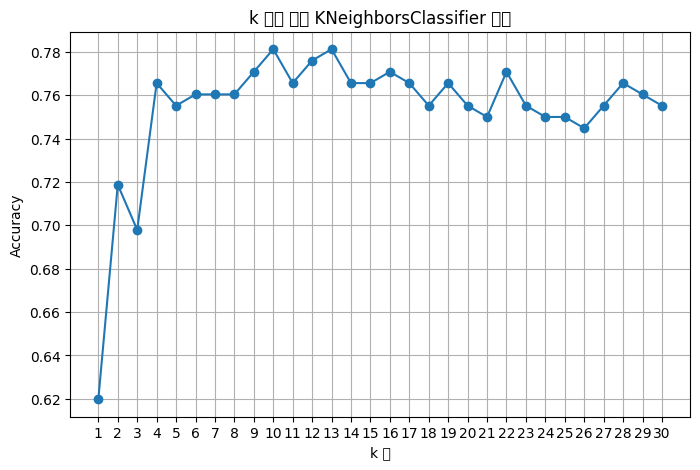

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

k_list = []
acc_list = []

#최적 k 찾기
for k in range(1, 31):
    clf_knn = KNeighborsClassifier(n_neighbors=k)
    clf_knn.fit(X_train, y_train)

    pred_knn = clf_knn.predict(X_test)

    acc = accuracy_score(y_test, pred_knn)

    k_list.append(k)
    acc_list.append(acc)

best_k = k_list[np.argmax(acc_list)]
best_acc = max(acc_list)

print("\n--- KNeighborsClassifier 최적화 결과 ---")
print("최적의 k:", best_k)
print("최고 정확도:", best_acc)

# 최적 k로 다시 학습
best_model = KNeighborsClassifier(n_neighbors=best_k)
best_model.fit(X_train, y_train)
pred_knn = best_model.predict(X_test)

print("\n--- KNeighborsClassifier ---")
print("정확도:", accuracy_score(y_test, pred_knn))
print("혼동행렬:\n", confusion_matrix(y_test, pred_knn))

# 그래프
plt.figure(figsize=(8, 5))
plt.plot(k_list, acc_list, marker='o')
plt.xlabel("k 값")
plt.ylabel("Accuracy")
plt.title("k 값에 따른 KNeighborsClassifier 성능")
plt.xticks(range(1, 31))
plt.grid(True)
plt.show()